# **Hotel Booking Data Analytics Project**

## **Project Overview**

### **Business Problem**

This project analyzes hotel booking data to identify patterns in cancellation behavior, booking characteristics, guest behavior, room assignment, and guest origin markets.

### **Objective**

The objective is to use descriptive data analysis and visualization to identify meaningful patterns that can support hotel booking and demand-management decisions.

### **Business Questions**

1. What is the cancellation rate for bookings with a long lead time (>90 days) compared to short lead time bookings (<30 days)?

2. How frequently are reserved room types reassigned to a different room type, and how does ADR differ between reassigned and non-reassigned bookings?

3. Do bookings with special requests or parking requirements have a different cancellation rate compared with bookings with zero requests?

4. How do repeat guests compare with first-time guests in terms of cancellation rates and average lead times?

5. Which guest origin countries have the highest cancellation rates among markets with at least 500 total bookings?

## 2. **Data Loading**

The hotel booking dataset was provided through a Google Sheet. The data was loaded into a pandas DataFrame for analysis, and the reservation status date was converted to a datetime format for consistent processing.

In [1]:
import pandas as pd
from google.colab import auth
import gspread
from google.auth import default

# Authenticate with Google
auth.authenticate_user()

# Authorize access to Google Sheets
creds, _ = default()
gc = gspread.authorize(creds)

# Google Sheets source
sheet_url = "https://docs.google.com/spreadsheets/d/1Weu4h8XXlHKaV7jXUrzH7SJrCR8xeo1u3ZFiwo2Pmlc/edit?usp=sharing"

# Open the spreadsheet and select the first worksheet
sh = gc.open_by_url(sheet_url)
worksheet = sh.get_worksheet(0)

# Load the worksheet into a DataFrame
data = worksheet.get_all_records()
df = pd.DataFrame(data)

# Convert date column to datetime
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"],
    errors="coerce"
)

# Basic dataset check
print("Dataset shape:", df.shape)
print("\nReservation status date datatype:")
print(df["reservation_status_date"].dtype)

# Display first five rows
df.head()

Dataset shape: (87230, 37)

Reservation status date datatype:
datetime64[ns]


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,val_stay_length_check,val_negative_values,val_cancellation_check,val_date_check
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,FLAG: 0 Night Stay,PASS,PASS,PASS
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,FLAG: 0 Night Stay,PASS,PASS,PASS
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,PASS,PASS,PASS,PASS
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,PASS,PASS,PASS,PASS
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,PASS,PASS,PASS,PASS


In [2]:
print("Missing values in reservation_status_date:",
      df["reservation_status_date"].isna().sum())

Missing values in reservation_status_date: 0


## **Dataset Understanding and Data Preparation**

Before performing the business analysis, the dataset was inspected to understand its structure, data types, completeness, and potential data-quality issues.

In [3]:
# 1. Number of rows and 2. Number of columns
print("=== 1 & 2. DATASET SHAPE (Rows, Columns) ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*50 + "\n")

# 3. Column names & 4. Data types
print("=== 3 & 4. COLUMN NAMES AND DATA TYPES ===")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# 5. Summary statistics (Numerical & Categorical)
print("=== 5. SUMMARY STATISTICS (Numerical Columns) ===")
display(df.describe())
print("\n")

print("=== 5. SUMMARY STATISTICS (Categorical/Text Columns) ===")
display(df.describe(include=['object']))
print("\n" + "="*50 + "\n")

# 6. Unique values in categorical/text columns
print("=== 6. UNIQUE VALUES IN CATEGORICAL COLUMNS ===")
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"Column '{col}' has {df[col].nunique()} unique values:")
    print(df[col].value_counts().head(10))  # Shows top 10 unique values
    print("-" * 30)

print("\n" + "="*50 + "\n")

# 7. First 5 rows
print("=== 7. FIRST 5 ROWS ===")
display(df.head())

=== 1 & 2. DATASET SHAPE (Rows, Columns) ===
Rows: 87230, Columns: 37


=== 3 & 4. COLUMN NAMES AND DATA TYPES ===
hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                   int64
babies                                     int64
total_guest                                int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
pre

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,total_guest,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230.000000,87230
mean,0.275238,79.971019,2016.210352,26.835091,15.815832,1.004609,2.623925,1.879365,0.138897,0.010845,2.029107,0.038565,0.030402,0.184054,0.268497,0.746291,106.518031,0.084306,0.698934,2016-08-31 02:54:22.492261888
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.250000,0.000000,0.000000,2016-03-18 00:00:00
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.200000,0.000000,0.000000,2016-09-08 00:00:00
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.100000,0.000000,1.000000,2017-03-05 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,55.000000,1.000000,26.000000,72.000000,18.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.446637,86.058683,0.686064,13.669216,8.835545,1.027408,2.039830,0.621724,0.456265,0.113704,0.790141,0.192556,0.369344,1.733033,0.710633,10.001001,54.891227,0.281659,0.832051,NaN




=== 5. SUMMARY STATISTICS (Categorical/Text Columns) ===


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,agent,company,customer_type,reservation_status,val_stay_length_check,val_negative_values,val_cancellation_check,val_date_check
count,87230,87230,87230,87230,87230,87230,87230,87230,87230,87230,87230,87230,87230,87230,87230,87230,87230
unique,2,12,5,178,8,5,9,11,3,334,349,4,3,2,2,1,2
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,9,None,Transient,Check-Out,PASS,PASS,PASS,PASS
freq,53274,11242,67907,27355,51553,69028,56436,46283,86085,28721,81993,71862,63221,86662,87229,87230,64985




=== 6. UNIQUE VALUES IN CATEGORICAL COLUMNS ===
Column 'hotel' has 2 unique values:
hotel
City Hotel      53274
Resort Hotel    33956
Name: count, dtype: int64
------------------------------
Column 'arrival_date_month' has 12 unique values:
arrival_date_month
August       11242
July         10043
May           8344
April         7900
June          7756
March         7489
October       6921
September     6682
February      6083
December      5112
Name: count, dtype: int64
------------------------------
Column 'meal' has 5 unique values:
meal
BB         67907
SC          9391
HB          9080
No Meal      492
FB           360
Name: count, dtype: int64
------------------------------
Column 'country' has 178 unique values:
country
PRT    27355
GBR    10424
FRA     8823
ESP     7244
DEU     5385
ITA     3061
IRL     3015
BEL     2081
BRA     1993
NLD     1910
Name: count, dtype: int64
------------------------------
Column 'market_segment' has 8 unique values:
market_segment
Online TA     

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,val_stay_length_check,val_negative_values,val_cancellation_check,val_date_check
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,FLAG: 0 Night Stay,PASS,PASS,PASS
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,FLAG: 0 Night Stay,PASS,PASS,PASS
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,PASS,PASS,PASS,PASS
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,PASS,PASS,PASS,PASS
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,PASS,PASS,PASS,PASS


### Data Quality

The dataset was inspected for structure, missing values, duplicates, and potential invalid values before analysis. Validation checks were used to identify potential data-quality issues relevant to the analysis.

## Business Question 1 — Lead Time and Cancellation Rate

**Question:**

What is the cancellation rate for bookings with a long lead time (>90 days) compared to short lead time bookings (<30 days)?

=== Lead Time Cancellation Analysis Summary ===


,lead_time_group,total_bookings,canceled_bookings,cancellation_rate
0,Short Lead Time (< 30 days),33995,5510,16.21%
1,Long Lead Time (> 90 days),29981,11052,36.86%


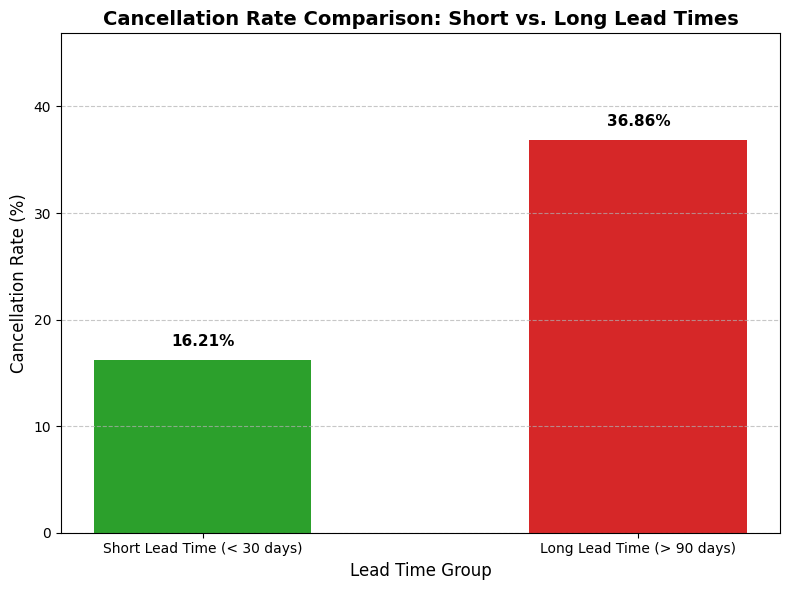

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a copy of the dataframe with only the required columns
lead_df = df[['lead_time', 'is_canceled', 'hotel']].copy()

# 2. Filter out bookings between 30 and 90 days (keeping < 30 and > 90 days)
filtered_df = lead_df[(lead_df['lead_time'] < 30) | (lead_df['lead_time'] > 90)].copy()

# 3. Assign lead-time group labels to the filtered data
filtered_df['lead_time_group'] = filtered_df['lead_time'].apply(
    lambda x: 'Short Lead Time (< 30 days)' if x < 30 else 'Long Lead Time (> 90 days)'
)

# 4. Calculate group metrics: total bookings, canceled count, and cancellation rate (%)
summary = filtered_df.groupby('lead_time_group').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancellation_rate=('is_canceled', lambda x: (x.sum() / x.count()) * 100)
).reset_index()

# Sort groups so "Short Lead Time" appears first
group_order = ['Short Lead Time (< 30 days)', 'Long Lead Time (> 90 days)']
summary['lead_time_group'] = pd.Categorical(summary['lead_time_group'], categories=group_order, ordered=True)
summary = summary.sort_values('lead_time_group').reset_index(drop=True)

# 5. Display the calculated results in a clean table format
print("=== Lead Time Cancellation Analysis Summary ===")
# Format cancellation rate column for readability in output table
summary_display = summary.copy()
summary_display['cancellation_rate'] = summary_display['cancellation_rate'].map('{:.2f}%'.format)
display(summary_display)

# 6. Create the visualization comparing cancellation rates
plt.figure(figsize=(8, 6))

bars = plt.bar(
    summary['lead_time_group'],
    summary['cancellation_rate'],
    color=['#2ca02c', '#d62728'],  # Green for short lead time, Red for long lead time
    width=0.5
)

# 7. Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 1,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# 8. Add titles, labels, and grid lines
plt.title('Cancellation Rate Comparison: Short vs. Long Lead Times', fontsize=14, fontweight='bold')
plt.xlabel('Lead Time Group', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

# Set y-axis limit slightly higher to leave space for labels on top of bars
plt.ylim(0, max(summary['cancellation_rate']) + 10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the chart
plt.show()

## **Observation:**
The cancellation rate increases from 16.21% for bookings made under 30 days in advance to 36.86% for bookings made over 90 days in advance.   

## **Business Insight:**
The further out a reservation is made, the higher the likelihood it will not result in a completed stay. This pattern highlights that inventory held far in the future represents a higher risk of turning into last-minute unfulfilled capacity.

## Business Question 2 — Room Reassignment and ADR

**Question:**

Which reserved room types are most frequently reassigned to a different room type upon check-in, and how does ADR differ between reassigned and non-reassigned bookings?

=== Missing Value Summary ===
reserved_room_type    0
assigned_room_type    0
adr                   0
dtype: int64
Note: Canceled bookings are excluded from ADR comparisons as they do not represent completed stays.


=== Room Reassignment Analysis Summary ===


,reassignment_status,total_bookings,pct_of_total_bookings,avg_adr
0,Not Reassigned,74240,85.11%,$106.46
1,Reassigned,12990,14.89%,$84.78


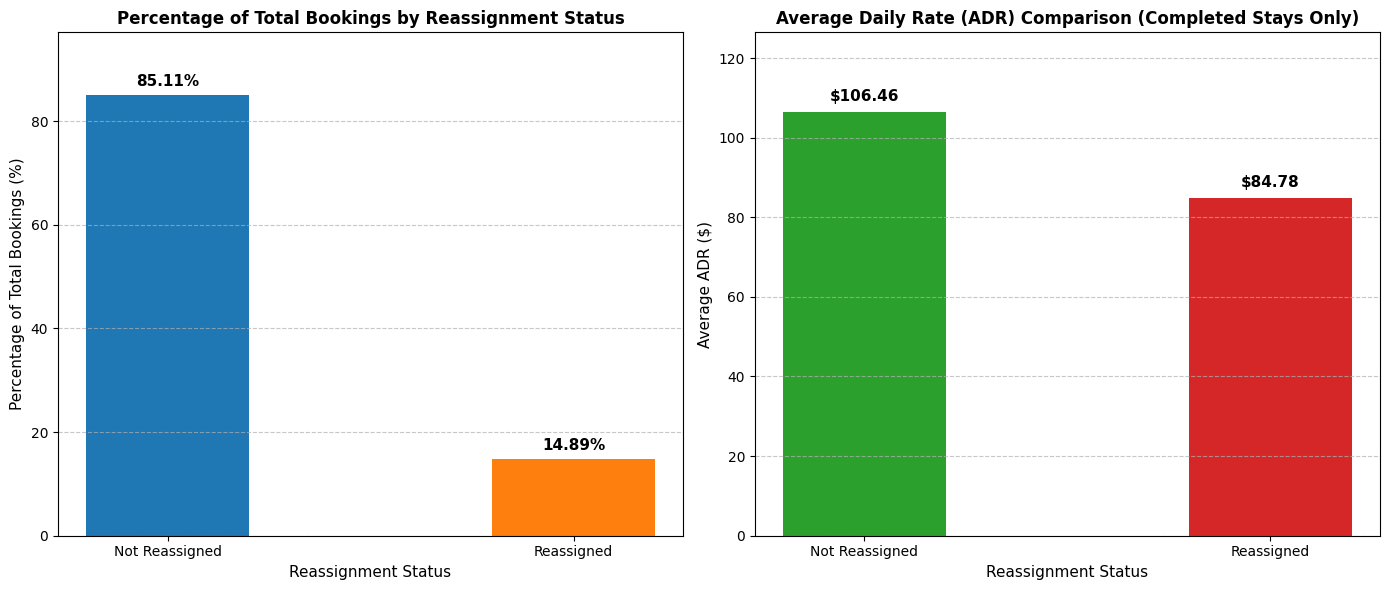

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Select the required columns from df
room_df = df[['reserved_room_type', 'assigned_room_type', 'adr', 'is_canceled']].copy()

# 2. Handle missing/null values if present in room type or adr columns
# Check for missing values across the required fields
missing_counts = room_df[['reserved_room_type', 'assigned_room_type', 'adr']].isna().sum()
print("=== Missing Value Summary ===")
print(missing_counts)
print("Note: Canceled bookings are excluded from ADR comparisons as they do not represent completed stays.")
print("\n" + "="*50 + "\n")

# Drop any rows where reserved/assigned room type or adr is missing
room_df = room_df.dropna(subset=['reserved_room_type', 'assigned_room_type', 'adr']).copy()

# 3. Create the Reassigned status label by comparing reserved vs assigned room types
room_df['reassignment_status'] = room_df.apply(
    lambda row: 'Reassigned' if row['reserved_room_type'] != row['assigned_room_type'] else 'Not Reassigned',
    axis=1
)

# 4. Calculate total bookings and percentage across ALL bookings (including canceled)
total_bookings_count = len(room_df)

booking_summary = room_df.groupby('reassignment_status').agg(
    total_bookings=('reassignment_status', 'count')
).reset_index()

booking_summary['pct_of_total_bookings'] = (booking_summary['total_bookings'] / total_bookings_count) * 100

# 5. Calculate Average ADR for completed stays only (excluding canceled bookings where is_canceled == 1)
completed_stays = room_df[room_df['is_canceled'] == 0]

adr_summary = completed_stays.groupby('reassignment_status').agg(
    avg_adr=('adr', 'mean')
).reset_index()

# 6. Merge metrics into one comprehensive summary table
summary_table = pd.merge(booking_summary, adr_summary, on='reassignment_status')

# Order rows logically: 'Not Reassigned' first, then 'Reassigned'
summary_table['reassignment_status'] = pd.Categorical(
    summary_table['reassignment_status'],
    categories=['Not Reassigned', 'Reassigned'],
    ordered=True
)
summary_table = summary_table.sort_values('reassignment_status').reset_index(drop=True)

# 7. Display formatted summary table
print("=== Room Reassignment Analysis Summary ===")
summary_display = summary_table.copy()
summary_display['pct_of_total_bookings'] = summary_display['pct_of_total_bookings'].map('{:.2f}%'.format)
summary_display['avg_adr'] = summary_display['avg_adr'].map('${:.2f}'.format)
display(summary_display)

# 8. Create a figure with 2 subplots (side-by-side visualizations)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Chart 1: Percentage of Bookings (Reassigned vs Not Reassigned) ---
bars1 = ax1.bar(
    summary_table['reassignment_status'],
    summary_table['pct_of_total_bookings'],
    color=['#1f77b4', '#ff7f0e'],
    width=0.4
)

# Add percentage data labels on top of Chart 1
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 1,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax1.set_title('Percentage of Total Bookings by Reassignment Status', fontsize=12, fontweight='bold')
ax1.set_xlabel('Reassignment Status', fontsize=11)
ax1.set_ylabel('Percentage of Total Bookings (%)', fontsize=11)
ax1.set_ylim(0, max(summary_table['pct_of_total_bookings']) + 12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Chart 2: Average ADR Comparison (Completed Stays Only) ---
bars2 = ax2.bar(
    summary_table['reassignment_status'],
    summary_table['avg_adr'],
    color=['#2ca02c', '#d62728'],
    width=0.4
)

# Add dollar labels on top of Chart 2
for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 2,
        f'${height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax2.set_title('Average Daily Rate (ADR) Comparison (Completed Stays Only)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Reassignment Status', fontsize=11)
ax2.set_ylabel('Average ADR ($)', fontsize=11)
ax2.set_ylim(0, max(summary_table['avg_adr']) + 20)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Observation:**
Most bookings were assigned to their reserved room type, and these bookings had a higher observed average ADR than reassigned bookings. This shows an association between room reassignment status and ADR among completed stays.

## **Business Insight:**
The vast majority of bookings (85.11%) remain in their reserved room type and capture higher average daily rates ($106.46 vs. $84.78). This indicates an observed correlation where stays with lower average daily rates represent the primary group experiencing room reassignments, whereas higher ADR bookings coincide less frequently with reassignments.


## Business Question 3 — Special Requests, Parking and Cancellation

**Question:**

Do guests who submit special requests or request parking spaces have a different cancellation rate compared with guests with zero requests?

=== Missing Value Summary ===
total_of_special_requests      0
required_car_parking_spaces    0
is_canceled                    0
dtype: int64


=== Cancellation Rate by Requests/Parking Group ===


,engagement_group,total_bookings,canceled_bookings,cancellation_rate
0,No Requests or Parking,40711,14561,35.77%
1,At Least 1 Request or Parking,46519,9448,20.31%


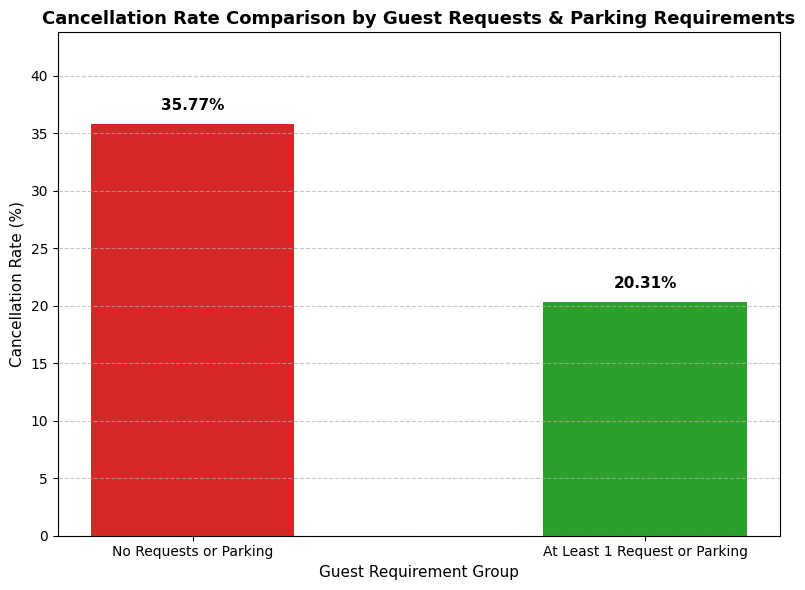

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Select the required columns from df
request_df = df[['total_of_special_requests', 'required_car_parking_spaces', 'is_canceled']].copy()

# 2. Check and handle missing/null values across required fields
missing_summary = request_df.isna().sum()
print("=== Missing Value Summary ===")
print(missing_summary)
print("\n" + "="*50 + "\n")

# Drop rows with missing values if any exist to ensure no invalid counts
request_df = request_df.dropna().copy()

# 3. Create mutually exclusive groups (each booking is counted exactly once)
# Group 1: Zero special requests AND zero parking spaces
# Group 2: At least one special request OR at least one parking space
request_df['engagement_group'] = request_df.apply(
    lambda row: 'No Requests or Parking'
    if (row['total_of_special_requests'] == 0 and row['required_car_parking_spaces'] == 0)
    else 'At Least 1 Request or Parking',
    axis=1
)

# 4. Aggregate metrics for each group: total bookings, canceled bookings, and cancellation rate (%)
summary_table = request_df.groupby('engagement_group').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancellation_rate=('is_canceled', lambda x: (x.sum() / x.count()) * 100)
).reset_index()

# Sort rows to display 'No Requests or Parking' first
group_order = ['No Requests or Parking', 'At Least 1 Request or Parking']
summary_table['engagement_group'] = pd.Categorical(
    summary_table['engagement_group'],
    categories=group_order,
    ordered=True
)
summary_table = summary_table.sort_values('engagement_group').reset_index(drop=True)

# 5. Display the formatted summary table
print("=== Cancellation Rate by Requests/Parking Group ===")
summary_display = summary_table.copy()
summary_display['cancellation_rate'] = summary_display['cancellation_rate'].map('{:.2f}%'.format)
display(summary_display)

# 6. Create the bar chart visualization
plt.figure(figsize=(8, 6))

bars = plt.bar(
    summary_table['engagement_group'],
    summary_table['cancellation_rate'],
    color=['#d62728', '#2ca02c'],  # Red for no requests, Green for requests/parking
    width=0.45
)

# 7. Add percentage data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 1,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Set chart labels, title, and gridlines
plt.title('Cancellation Rate Comparison by Guest Requests & Parking Requirements', fontsize=13, fontweight='bold')
plt.xlabel('Guest Requirement Group', fontsize=11)
plt.ylabel('Cancellation Rate (%)', fontsize=11)
plt.ylim(0, max(summary_table['cancellation_rate']) + 8)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Observation:**
Bookings with no special requests or parking requirements have a cancellation rate of 35.77%, whereas bookings with at least one request or parking requirement have a cancellation rate of 20.31%.   

## **Business Insight:**
Bookings with at least one special request or parking requirement have a substantially lower observed cancellation rate than bookings with neither. This indicates that bookings involving these guest requirements are associated with more reliable booking follow-through.

## Business Question 4 — Repeat Guests and Booking Behaviour

**Question:**

How do repeat guests compare with first-time guests in terms of cancellation rates and average lead times?

=== Missing Value Summary ===
is_repeated_guest                 0
is_canceled                       0
lead_time                         0
previous_bookings_not_canceled    0
dtype: int64


=== Guest Loyalty Analysis Summary ===


,guest_category,total_bookings,canceled_bookings,cancellation_rate,avg_lead_time,avg_prev_non_canceled
0,First-Time Guest,83866,23749,28.32%,82.48 days,0.03
1,Repeat Guest,3364,260,7.73%,17.33 days,4.03


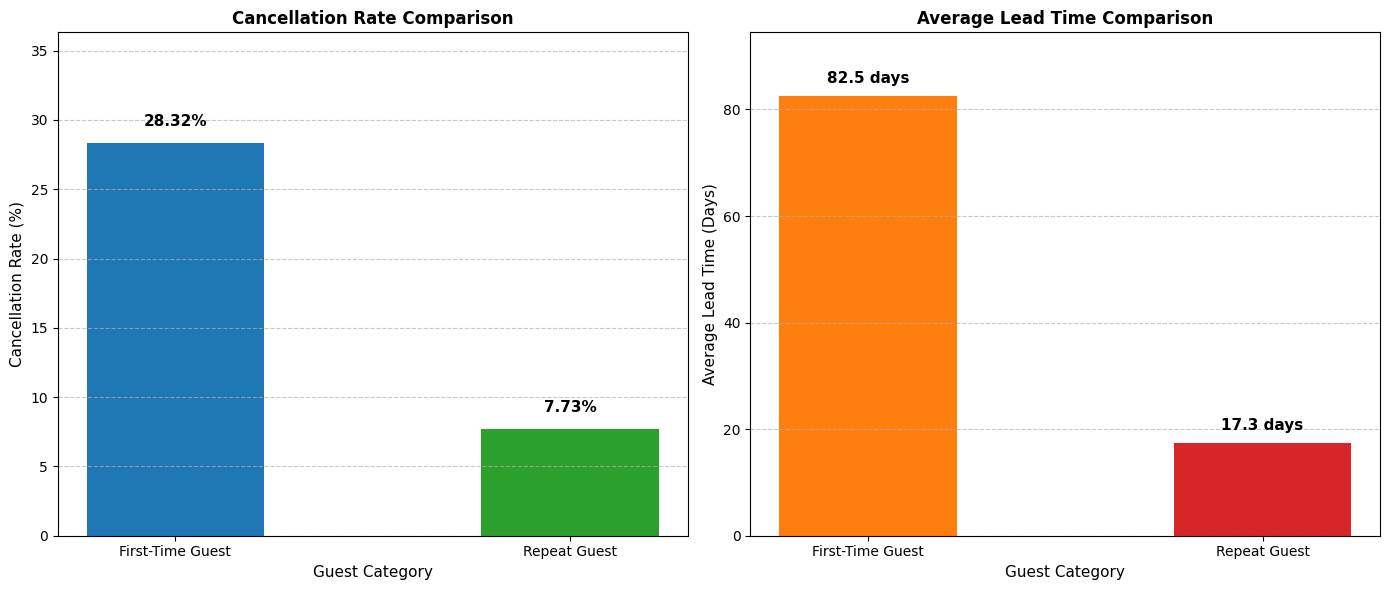

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Select the required columns from df
guest_df = df[['is_repeated_guest', 'is_canceled', 'lead_time', 'previous_bookings_not_canceled']].copy()

# 2. Check for missing/null values across required fields
missing_summary = guest_df.isna().sum()
print("=== Missing Value Summary ===")
print(missing_summary)
print("\n" + "="*50 + "\n")

# Drop any rows with missing values if present to keep calculations consistent
guest_df = guest_df.dropna().copy()

# 3. Create guest category labels using is_repeated_guest (1 = Repeat Guest, 0 = First-Time Guest)
guest_df['guest_category'] = guest_df['is_repeated_guest'].apply(
    lambda x: 'Repeat Guest' if x == 1 else 'First-Time Guest'
)

# 4. Aggregate metrics by guest category
summary_table = guest_df.groupby('guest_category').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancellation_rate=('is_canceled', lambda x: (x.sum() / x.count()) * 100),
    avg_lead_time=('lead_time', 'mean'),
    avg_prev_non_canceled=('previous_bookings_not_canceled', 'mean')
).reset_index()

# Sort rows to show First-Time Guest first, then Repeat Guest
category_order = ['First-Time Guest', 'Repeat Guest']
summary_table['guest_category'] = pd.Categorical(
    summary_table['guest_category'],
    categories=category_order,
    ordered=True
)
summary_table = summary_table.sort_values('guest_category').reset_index(drop=True)

# 5. Display the formatted summary table
print("=== Guest Loyalty Analysis Summary ===")
summary_display = summary_table.copy()
summary_display['cancellation_rate'] = summary_display['cancellation_rate'].map('{:.2f}%'.format)
summary_display['avg_lead_time'] = summary_display['avg_lead_time'].map('{:.2f} days'.format)
summary_display['avg_prev_non_canceled'] = summary_display['avg_prev_non_canceled'].map('{:.2f}'.format)
display(summary_display)

# 6. Create two separate subplots side-by-side to prevent scale mismatch between % and days
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Chart 1: Cancellation Rate Comparison ---
bars1 = ax1.bar(
    summary_table['guest_category'],
    summary_table['cancellation_rate'],
    color=['#1f77b4', '#2ca02c'],
    width=0.45
)

# Add percentage labels on top of Chart 1
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 1,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax1.set_title('Cancellation Rate Comparison', fontsize=12, fontweight='bold')
ax1.set_xlabel('Guest Category', fontsize=11)
ax1.set_ylabel('Cancellation Rate (%)', fontsize=11)
ax1.set_ylim(0, max(summary_table['cancellation_rate']) + 8)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Chart 2: Average Lead Time Comparison ---
bars2 = ax2.bar(
    summary_table['guest_category'],
    summary_table['avg_lead_time'],
    color=['#ff7f0e', '#d62728'],
    width=0.45
)

# Add day count labels on top of Chart 2
for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 2,
        f'{height:.1f} days',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax2.set_title('Average Lead Time Comparison', fontsize=12, fontweight='bold')
ax2.set_xlabel('Guest Category', fontsize=11)
ax2.set_ylabel('Average Lead Time (Days)', fontsize=11)
ax2.set_ylim(0, max(summary_table['avg_lead_time']) + 12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Observation:**
First-time guests have a cancellation rate of 28.32% and an average lead time of 82.5 days, while repeat guests have a cancellation rate of 7.73% and an average lead time of 17.3 days.   

## **Business Insight:**
Repeat guests represent a significantly lower cancellation risk and book much closer to their arrival date compared to first-time guests. This indicates that repeat guest bookings are substantially more reliable for short-term occupancy, whereas first-time guest bookings require longer forecasting windows and carry higher drop-off risk.

## Business Question 5 — Origin Markets and Cancellation Rate

**Question:**

Which guest origin countries have the highest cancellation rates among markets with at least 500 total bookings?

=== Missing Country Value Summary ===
Rows excluded due to missing/null/unknown country: 447


=== Top Country Cancellation Rates (Min. 500 Bookings) ===


,country,total_bookings,canceled_bookings,cancellation_rate
0,CHN,816,392,48.04%
1,RUS,559,222,39.71%
2,BRA,1993,727,36.48%
3,PRT,27355,9782,35.76%
4,ITA,3061,1075,35.12%
5,NOR,515,145,28.16%
6,ESP,7244,1862,25.70%
7,USA,1871,459,24.53%
8,CHE,1566,384,24.52%
9,IRL,3015,668,22.16%


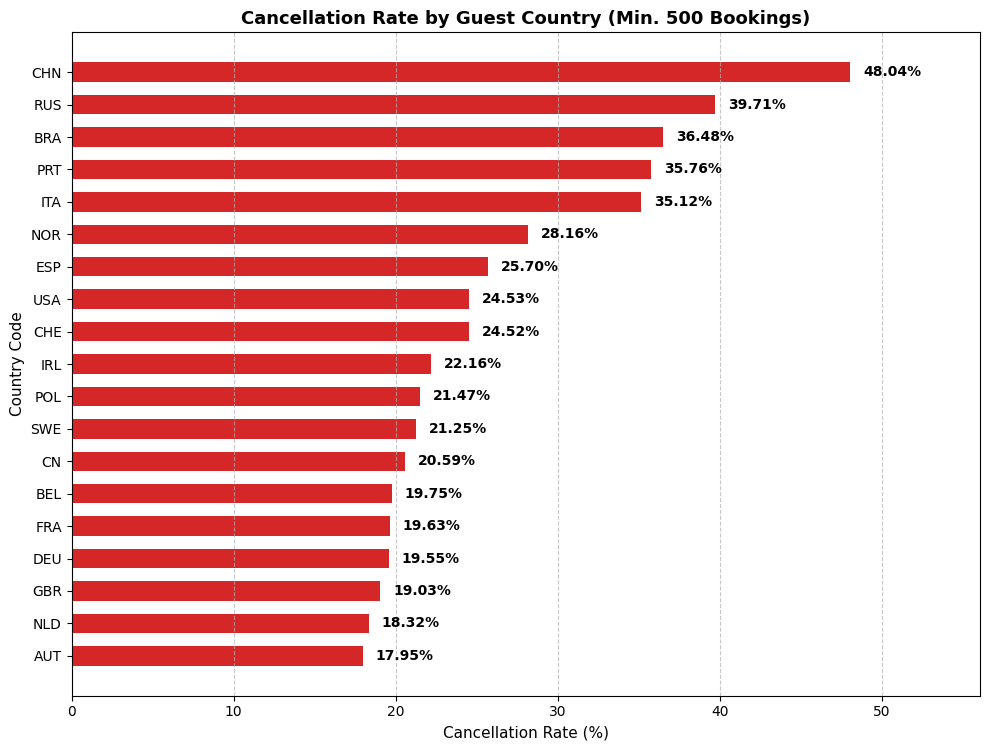

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Select the required columns from df
country_df = df[['country', 'is_canceled']].copy()

# 2. Check for missing/null country values
missing_country_count = country_df['country'].isna().sum() + (country_df['country'] == 'NULL').sum() + (country_df['country'] == 'Unknown').sum()
print("=== Missing Country Value Summary ===")
print(f"Rows excluded due to missing/null/unknown country: {missing_country_count}")
print("\n" + "="*50 + "\n")

# Exclude missing or placeholder country values (do not invent or reassign countries)
valid_country_df = country_df[
    country_df['country'].notna() &
    (~country_df['country'].isin(['NULL', 'Unknown', 'TMP']))
].copy()

# 3. Group by country and aggregate metrics
country_summary = valid_country_df.groupby('country').agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    cancellation_rate=('is_canceled', lambda x: (x.sum() / x.count()) * 100)
).reset_index()

# 4. Filter to include ONLY countries with at least 500 total bookings
eligible_countries = country_summary[country_summary['total_bookings'] >= 500].copy()

# 5. Sort eligible countries by cancellation rate from highest to lowest
eligible_countries = eligible_countries.sort_values(by='cancellation_rate', ascending=False).reset_index(drop=True)

# 6. Display the formatted summary table
print("=== Top Country Cancellation Rates (Min. 500 Bookings) ===")
summary_display = eligible_countries.copy()
summary_display['cancellation_rate'] = summary_display['cancellation_rate'].map('{:.2f}%'.format)
display(summary_display)

# 7. Create horizontal bar chart (sorted so highest cancellation rate appears at the top)
chart_data = eligible_countries.sort_values(by='cancellation_rate', ascending=True).reset_index(drop=True)

# Dynamically set figure height based on the number of eligible countries for readability
plt.figure(figsize=(10, max(6, len(chart_data) * 0.4)))

bars = plt.barh(
    chart_data['country'],
    chart_data['cancellation_rate'],
    color='#d62728',
    height=0.6
)

# 8. Add percentage data labels onto each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2.0,
        f'{width:.2f}%',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# 9. Format chart title, axes, and gridlines
plt.title('Cancellation Rate by Guest Country (Min. 500 Bookings)', fontsize=13, fontweight='bold')
plt.xlabel('Cancellation Rate (%)', fontsize=11)
plt.ylabel('Country Code', fontsize=11)

# Extend x-axis limit slightly to fit the end labels cleanly
plt.xlim(0, max(eligible_countries['cancellation_rate']) + 8)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the chart
plt.show()

## **Observation:**
Among origin markets with at least 500 bookings, China (CHN) exhibits the highest cancellation rate at 48.04%, followed by Russia (RUS) at 39.71% and Brazil (BRA) at 36.48%. Austria (AUT) shows the lowest cancellation rate among the displayed group at 17.95%.

## **Business Insight:**
Cancellation rates vary substantially across high-volume origin markets, ranging from 17.95% in Austria to 48.04% in China. This indicates that cancellation risk differs considerably across guest origin markets and may be relevant when forecasting booking demand.  

# **Hypothesis:**
The following hypotheses are possible explanations for patterns identified during the analysis. They are not treated as proven causal explanations.

1. Guests booking several months in advance may face greater uncertainty regarding work schedules, personal commitments, or financial situations as the arrival date approaches. This increased likelihood of unexpected schedule changes might result in higher cancellation rates compared to near-term bookings where plans are already finalized.
2. Bookings requiring parking or special accommodations could represent specific trip types, such as family vacations or road trips, which involve greater logistical coordination (e.g., driving, scheduling). Because these trips are often planned around fixed events or family needs, they possibly carry lower flexibility to cancel or change plans at the last minute.
3. Returning guests could be booking for routine travel—such as recurring business trips, local weekend getaways, or regular family visits—which are often scheduled on shorter notice. Because these trips possibly stem from known, fixed schedules, they are finalized close to the arrival date and carry very little risk of cancellation.

# **Recommendations:**
The following recommendations are proposed based on the observed patterns and insights from the analysis.
1. Set up automated communication workflows (e.g., email or SMS check-ins) sent at key intervals—such as 60, 30, and 14 days prior to arrival—for long lead-time reservations. Encouraging guests to confirm details, customize their stay, or request add-ons helps re-verify guest intent early, while providing early visibility into potential cancellations if plans have changed.
2. Send targeted follow-up messages to bookings with zero special requests and zero parking requirements before arrival. The communication could provide guests with opportunities to customize their stay or request additional services, while also providing another opportunity to confirm their booking.
3. Reserve a dedicated portion of last-minute room inventory specifically for past guests by offering preferred short-notice rates or complimentary upgrades. Leveraging returning guests to fill remaining near-term capacity helps capture high-probability bookings close to arrival without relying on deep public discounts.

# **Overall Conclusion:**
The analysis identified several differences in booking and cancellation behaviour across lead time, room assignment, guest requirements, repeat-guest status, and origin markets. Long-lead-time bookings showed higher observed cancellation rates, while repeat guests showed lower cancellation rates and shorter booking lead times. Cancellation rates also varied substantially across high-volume origin markets. Room reassignment was observed in a minority of bookings and was associated with a lower average ADR among non-canceled bookings. These findings highlight areas where booking behaviour can be monitored more closely and where targeted communication and customer-focused strategies could be evaluated.